# Supervised Machine Learning: feature selection
Feature selection is aimed at identifying and selecting the most relevant and informative features from a given dataset. With the abundance of available features, selecting the right subset of variables can significantly impact the model's performance. By pruning irrelevant or redundant features, feature selection not only enhances the accuracy and generalisation capabilities of models but also reduces computational complexity, ensuring faster and more efficient predictions.

---
## 1.&nbsp;Import libraries 💾

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFECV, SelectFromModel
from sklearn.pipeline import make_pipeline

In [11]:
from sklearn import set_config
set_config(transform_output='pandas')

---
## 2.&nbsp;Creating the Dataset for Feature Selection 📂

In this step, we'll construct a diverse dataset. It includes both informative columns (strongly related to the label) and irrelevant ones (without any meaningful association with the label). You don't need to understand the intricacies of the dataset generation code; our focus lies in the feature selection we will perform on this dataset, rather than on the dataset generation itself.

In [12]:
np.random.seed(123)
scale_values = np.logspace(1, 10, num=25)

X, y = make_regression(n_samples=1000,
                       n_features=25,
                       n_informative=6,
                       effective_rank=4,
                       noise=0.2,
                       random_state=42)

X = pd.DataFrame(X)
y = pd.DataFrame(y)

new_columns = {
    "25": np.random.normal(scale=1.1, loc=0.01, size=len(X)),
    "26": np.random.normal(scale=4, loc=1, size=len(X)),
    "27": np.full(len(X), 1.),
    "28": np.full(len(X), 0.),
    "29": np.concatenate([np.zeros(len(X)-1), [0.1]]),
    "30": X.iloc[:,3] * 0.823,
    "31": X.iloc[:,8] * np.random.normal(scale=0.3, loc=1, size=len(X))
}

X = X.assign(**new_columns)
X = X.add_prefix("feature_")
y = y.rename(columns={0:"label"})

original_df = pd.concat([X, y], axis=1)
original_df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,label
0,-0.018296,-0.001839,0.016016,-0.019307,0.001856,0.027113,0.013745,0.000633,0.017954,-0.009104,...,0.017348,-0.011803,-1.184194,-1.995310,1.0,0.0,0.0,-0.015890,0.008398,-0.076775
1,0.001363,-0.034291,-0.001782,-0.001157,-0.000928,0.021803,-0.017609,0.001054,0.000947,-0.016167,...,-0.023567,0.020733,1.107080,3.270379,1.0,0.0,0.0,-0.000952,0.000606,1.945816
2,-0.007991,0.013612,0.008775,-0.004530,0.002792,0.009852,0.004221,0.002174,-0.007749,0.016543,...,-0.005296,-0.006772,0.321276,3.872602,1.0,0.0,0.0,-0.003728,-0.010298,1.261298
3,-0.012161,0.021575,-0.008932,-0.007190,-0.010184,-0.016184,0.001812,-0.008250,-0.008352,-0.009462,...,-0.001067,0.006821,-1.646924,-2.997523,1.0,0.0,0.0,-0.005918,-0.010509,-4.510620
4,-0.029442,-0.005390,0.011258,0.024444,0.013054,-0.012449,-0.026195,0.025240,0.007042,-0.005765,...,-0.022302,0.011463,-0.626460,2.899593,1.0,0.0,0.0,0.020117,0.003830,3.017716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.004784,-0.005852,0.003786,-0.018332,0.017759,-0.011987,-0.019495,0.006243,0.014125,-0.007231,...,-0.017950,0.018817,0.708239,4.382805,1.0,0.0,0.0,-0.015087,0.013806,2.110393
996,0.029737,0.009150,0.011322,0.026551,0.007310,0.003309,-0.007107,0.021561,0.021082,0.020325,...,0.005461,-0.018409,1.186910,-3.479690,1.0,0.0,0.0,0.021852,0.015098,0.666808
997,0.009199,0.012291,0.021928,0.021705,-0.006578,-0.036746,-0.037261,-0.009584,0.019986,0.008848,...,-0.027405,0.007829,-0.990260,-0.437187,1.0,0.0,0.0,0.017864,0.032221,-1.141679
998,-0.002704,-0.011813,-0.002855,0.019239,0.000741,0.017812,-0.010176,0.000241,-0.010978,-0.002322,...,0.022012,-0.015817,0.527290,-5.438780,1.0,0.0,0.0,0.015834,-0.014323,-2.718885


---
## 3.&nbsp;Train-test split 🔀

All data transformations and feature selection should rely solely on the information from the training set, with no consideration of the test set. In feature selection, this involves deciding the usefulness of columns based only on the training set. Once we identify which columns to drop, we apply the same removal to the test set as well. For custom feature selection without SKLearn, it is vital to adhere to this principle of excluding any information from the test set during the feature selection process.

In [13]:
X = original_df.copy()
y = X.pop("label")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

---
## 4.&nbsp;Baseline Model 🧱

In this codealong, we will focus on comparing the performance of two models: a Decision Tree with default parameters, and a K-Nearest Neighbors model with K=1. For simplicity, we won't be tuning the model hyperparameters here. However, you are encouraged to explore hyperparameter tuning independently. After applying each new feature selection strategy, we will track and evaluate the models to understand their impact on the predictive performance.

In [14]:
def score_models(feat_select_method, X_train, y_train, X_test, y_test):
  # KNN is affected by scaling
  scaler = MinMaxScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # Fit the models
  tree = DecisionTreeRegressor(random_state=42)
  tree.fit(X_train, y_train)
  knn = KNeighborsRegressor(n_neighbors=1)
  knn.fit(X_train, y_train)

  # Score their predictions
  scores = {
      'Feature Selection': feat_select_method,
      'Decision Tree': r2_score(y_test, tree.predict(X_test)),
      'KNN': r2_score(y_test, knn.predict(X_test))
  }
  return scores
method_scores = []

In this evaluation, we will utilise R-squared to assess our models' performance and gauge the impact of our feature selection process. While having a primary metric is recommended, exploring multiple metrics can provide diverse insights into the model's behavior. Therefore, feel free to explore alternative evaluation metrics to gain a more comprehensive understanding of your model's strengths and weaknesses.

In [15]:
method_scores.append(score_models('Baseline', X_train, y_train, X_test, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195


You can already see how a Decision Tree handles a noisy dataset much better than K-Nearest Neighbors. Decision Trees selectively consider only the "best" features in the algorithm, while K-Nearest Neighbors treats all features equally. However, it's essential to remember that the Decision Tree might not always be the better choice; after preprocessing, K-Nearest Neighbors could potentially perform better.

> **Note:** A negative R-squared score suggests that the KNN model performs worse than a horizontal line, indicating that it fails to capture any meaningful relationships between the input features and the target variable.

---
## 5.&nbsp;Feature selection based only on features 🔨

### 5.1.&nbsp;Variance Threshold

Features with low variance don't allow us to descriminate between different data points. You can imagine if we had a column in our housing dataset called "is_house" that was true for all the houses, it couldn't possible help us distinguish between expensive and inexpesive ones. With this transformer, we can eliminate those features with too little variance by setting a threshold. Any feature with a variance below this threshold will be dropped from the dataset. It's essential to consider that column variance is influenced by its scale; while most columns in our dataset have a small range, features 25 and 26 stand out with more significant variability.

Let's first look at the range and variance of the columns.

In [16]:
range_var_df = (pd.DataFrame({
                'Range': X_train.max() - X_train.min(),
                'Variance': X_train.var()})
                .sort_values(by='Variance'))

In [17]:
range_var_df.head()

,Range,Variance
feature_27,0.000000,0.000000
feature_28,0.000000,0.000000
feature_29,0.100000,0.000013
feature_4,0.084589,0.000134
feature_2,0.080179,0.000136


In [18]:
range_var_df.tail()

,Range,Variance
feature_5,0.112041,0.000342
feature_14,0.125454,0.000366
feature_13,0.146743,0.000426
feature_25,7.412498,1.206981
feature_26,25.429091,14.743576


The large variance observed in columns 25 and 26 could be attributed to their wider value range. It's important to note that this makes a direct comparison of their variances with other columns less meaningful due to the scale differences. Therefore, **it's a good idea to scale the features before removing those with the smallest variance**.

#### 5.1.1.&nbsp;Scaling the data

Certain scaling processes can result in transforming features to have the same variance, like the standard scaler, which changes the standard deviation to 1. However, this is **not** our desired outcome. We need to choose a scaler that preserves variance, and for this purpose, we will use min-max scaling.

In [19]:
# Initialize the scaler.
my_scaler = MinMaxScaler()

# Fit the scaler to X_train and transform the values.
X_train_scaled = my_scaler.fit_transform(X_train)

Let's examine how the scaling impacted the range and variance of our columns, with a specific focus on columns 25 and 26.

In [20]:
(
  pd.DataFrame({
  'Range': X_train_scaled.max() - X_train_scaled.min(),
  'Variance': X_train_scaled.var()})
  .sort_values(by='Variance')
)

,Range,Variance
feature_27,0.0,0.000000
feature_28,0.0,0.000000
feature_29,1.0,0.001250
feature_9,1.0,0.015667
feature_22,1.0,0.016657
feature_4,1.0,0.018682
feature_13,1.0,0.019783
feature_2,1.0,0.021117
feature_0,1.0,0.021403
feature_12,1.0,0.021515


After scaling features 25 and 26 no longer have the largest variances. Now, we can proceed with applying the `VarianceThreshold` transformation.

All features with a smaller variance than the `threshold` will be deleted from the dataset.

In [21]:
selector = VarianceThreshold(threshold=0.02)

X_train_var = selector.fit_transform(X_train_scaled)

Let's check how many features were dropped:

In [22]:
print("shape before:", X_train_scaled.shape)
print("shape after:", X_train_var.shape)

shape before: (800, 32)
shape after: (800, 25)


We have dropped `7` features using a threshold of `0.02`. Feel free to adjust the threshold if you wish to drop more or fewer features.

> **Note:** It's generally not advisable to drop many features with this transformer, as some features might contain crucial information, even if they have low variance. For instance, consider a feature in the Housing dataset representing the number of "Private Helicopters." Though it may have a small variance due to most houses having `0` helicopters, the presence of one helicopter can significantly impact the house price. Hence, it's essential to be cautious when dropping features, and it is usually safe to remove only features with zero variance as they offer no valuable information.

The next step: make sure to transform the test set using the `transform` method. Remember not to use the `fit_transform` method, as it is reserved exclusively for the train set. This way, you ensure proper feature scaling without introducing data leakage from the test set into the model.

In [23]:
# Scale the test set
X_test_scaled = my_scaler.transform(X_test)

# Apply the variance threshold to the scaled test set
X_test_var = selector.transform(X_test_scaled)

Let's check how well our model performs with the new dataset.

In [24]:
method_scores.append(score_models('Variance Threshold (0.02)', X_train_var, y_train, X_test_var, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197


Although the performance of our K-Nearest Neighbors model improved, the Decision Tree model's performance degraded significantly, implying that the dropped columns contained valuable information. Such outcomes are not uncommon when using the variance threshold.

Let's repeat the process with a more conservative threshold to explore if it makes a difference in preserving important features.

#### 5.1.2.&nbsp;Scaling the data: 2nd iteration
Set the threshold to 0, meaning we will remove only those columns with zero variance. This will help us eliminate features that carry no valuable information.

In [25]:
selector2 = VarianceThreshold(threshold=0)
X_train_var2 = selector2.fit_transform(X_train_scaled)

print("shape before:", X_train_scaled.shape)
print("shape after:", X_train_var2.shape)

shape before: (800, 32)
shape after: (800, 30)


We have only dropped 2 features that had zero variance. Let's see how this impacts performance.

In [26]:
X_test_var2 = selector2.transform(X_test_scaled)

In [27]:
method_scores.append(score_models('Variance Threshold (0.0)', X_train_var2, y_train, X_test_var2, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197
2,Variance Threshold (0.0),0.811580,0.338966


That's made an improvement in both models!

### 5.2.&nbsp; Collinearity

Features that have a perfect (or extremely high) correlation with each other can be considered to be the same feature. We want to drop one of them. Let's first explore the pairwise correlations between all features.

To quickly identify highly correlated columns, we can create a heatmap displaying their correlations, allowing us to easily spot extreme values.

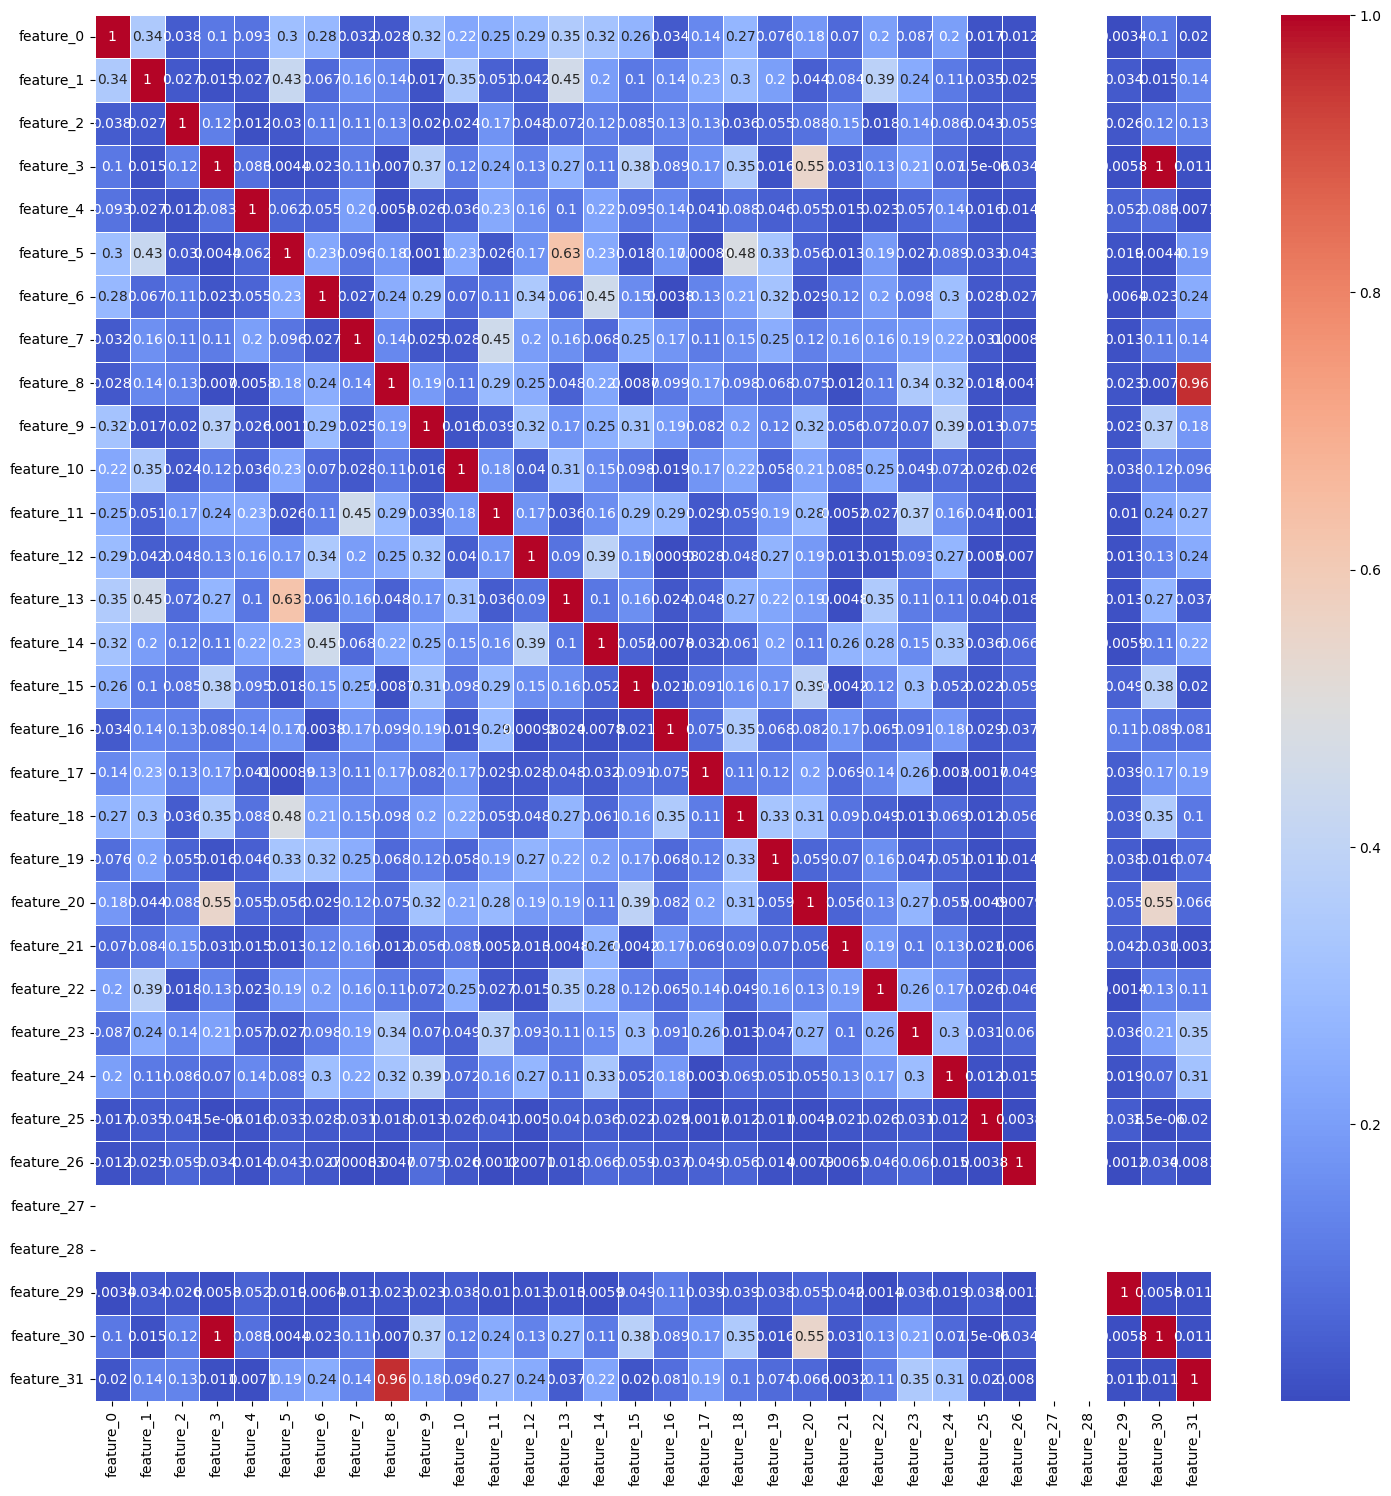

In [28]:
# Calculate the absolute correlation matrix for the feature matrix X_train_var2
corrMatrix = X_train.corr().abs()

# Set the size of the heatmap to be 18x18 inches
plt.figure(figsize=(18, 18))

# Create a heatmap using Seaborn (sns) to visualize the correlation matrix
# 'annot=True' adds the correlation values to the cells for better readability
# 'cmap='coolwarm'' specifies the color map to be used, with warm colors (red) for positive correlations
# and cool colors (blue) for negative correlations
# 'linewidths' sets the width of the white lines around the squares
sns.heatmap(corrMatrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5);

>**Note:** Columns 27 and 28 do not appear in the heatmap because they have 0 variance, meaning all their values are the same. When calculating the correlation coefficient, the denominator is the standard deviation of the column. As the standard deviation of these columns is 0, division by 0 occurs, resulting in NaN values.

From the heatmap we can see how there is a pair of columns with a _perfect_  correlation (`1`) and another pair of columns with a very high correlation (`0.96`). The rest of the correlation coefficients are much smaller and can be neglected at this stage.

If you have too many column to view on a heatmap, we can loop through the columns to identify the correlated columns.

In [29]:
# Set the correlation threshold to consider columns as highly correlated
correlation_threshold = 0.95

# Initialise an empty list to store the pairs of highly correlated columns
highly_correlated_columns = []

# Get the number of features (columns) in the correlation matrix
num_features = len(corrMatrix.columns)

# Loop through the upper triangle of the correlation matrix to find highly correlated columns
# Note: We start from i+1 to avoid redundancy as correlation_matrix is symmetric
for i in range(num_features):
    for j in range(i + 1, num_features):
        # Check if the correlation value between columns i and j is greater than or equal to the threshold
        if corrMatrix.iloc[i, j] >= correlation_threshold:
            # Append the tuple (column_i, column_j) to the list of highly correlated columns
            highly_correlated_columns.append((corrMatrix.columns[i], corrMatrix.columns[j], f"correlation = {round(corrMatrix.iloc[i, j], 2)}"))

# Print the pairs of highly correlated columns
print("Highly correlated columns:", highly_correlated_columns)

Highly correlated columns: [('feature_3', 'feature_30', 'correlation = 1.0'), ('feature_8', 'feature_31', 'correlation = 0.96')]


Since each tuple in our list contains 2 columns, we need to ensure we drop only one of them.

In [30]:
to_drop = [element_a for element_a, element_b, element_c in highly_correlated_columns]
to_drop

['feature_3', 'feature_8']

After identifying the columns to drop, we proceed to remove them from both the train and the test sets.
> **Note:** Normally students do this outside of the pipeline; with correlation it's hard to include a custom function in the pipeline using [Function Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html). This is hard to do as it normally removes different columns from the train and test set. The best solution to this is to create a class and include fit and tranform methods in the class. As this is more advanced than our course, please ask you instructor for an example if you're feeling inquisitive.

In [31]:
# Drop the columns from the train set.
X_train_corr = X_train.drop(columns=to_drop).copy()

# Drop the columns from the test set.
X_test_corr = X_test.drop(columns=to_drop).copy()

Let's check the performance again:

In [32]:
method_scores.append(score_models('Collinearity Threshold (0.95)', X_train_corr, y_train, X_test_corr, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197
2,Variance Threshold (0.0),0.811580,0.338966
3,Collinearity Threshold (0.95),0.810997,-0.980851


We observe that collinearity had a minor impact compared to our baseline model. However, it did not contribute as significantly to improving the KNN model compared to setting the variance threshold to 0.

---
## 6.&nbsp;Feature selection based on features and labels 🔧

### 6.1.&nbsp;K Best

Select K Best allows us to use statistical tests like ANOVA or chi2 to rank and select the best features. Refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html) and [user guide](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection) to see the model's methods, understand its parameters, and explore examples. If the documentation seems challenging, search for tutorials online.

We will have to choose an appropriate statistical test based on the data type: for our regression problem, an f-test will be used. Visit [Ben Lambert's Youtube channel](https://www.youtube.com/watch?v=ie-MYQp1Nic&ab_channel=BenLambert) for detailed explanations and examples on the f-test.

In short, Scikit-Learn computes the f-statistic for each univariate linear model (one for each feature). The f-statistic measures how much better the linear model with a single feature predicts compared to using only a constant value. This "score" allows us to rank the features.

For better understanding, let's run the statistical test and examine the f-statistics of each feature. Most of these require scaling so we will use the scaled `X` features from earlier

In [33]:
# Run the univariate (= one feature at a time) linear regression tests.
f_stat, _ = f_regression(X_train_scaled, y_train)

# Create a DataFrame with the f-statistics and p-values.
f_test = pd.DataFrame({"f_stat":f_stat},
                      index=X_train.columns)

# Sort the values in the f-statistic column.
f_test.sort_values("f_stat", ascending=False)

,f_stat
feature_16,613.642293
feature_17,574.378182
feature_4,317.693750
feature_18,77.020510
feature_11,60.709343
feature_7,53.810295
feature_1,42.225456
feature_23,29.215578
feature_31,19.905804
feature_20,18.498722


Above, we have a ranking of the "best" features based on their individual predictive ability in a linear model. The SelectKBest transformer performs this test and allows you to control the number of "top" features to retain using the K parameter. For our initial selection, we will set K=10, but feel free to adjust this value as needed.

> **Note:** In a pipeline with `GridSearchCV`, you can fine-tune the `K` parameter by trying out various possible values, along with other preprocessing and modeling parameters. Machine Learning often involves automated search or optimisation techniques to find the best parameter values, and it is normal not to have to intuitively know the ideal parameter values from the outset.

In [34]:
# Initialise KBest, using the f-regression and setting k=10.
kbest = SelectKBest(score_func=f_regression, k=10)

As always, after initialising the transformer we fit it to the train set and transform both the train and the test set:

In [35]:
# Transform the train set.
X_train_kbest = kbest.fit_transform(X_train_scaled, y_train).copy()

# Transform the test set.
X_test_kbest = kbest.transform(X_test_scaled).copy()

Now, you can see how both the train and the test set have only 10 features.

In [36]:
X_train_kbest.shape, X_test_kbest.shape

((800, 10), (200, 10))

Let's see how our models perform with these 10 "best" features:

In [37]:
method_scores.append(score_models('Select K Best', X_train_kbest, y_train, X_test_kbest, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197
2,Variance Threshold (0.0),0.811580,0.338966
3,Collinearity Threshold (0.95),0.810997,-0.980851
4,Select K Best,0.830227,0.658212


The performance of both models has increased significantly! It's possible it would increase even more by tuning the value of `K`.

### 6.2. Select from model

[SelectFromModel](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html?highlight=selectfrommodel#sklearn.feature_selection.SelectFromModel) leverages the importance scores provided by a model to select the most relevant features from a given dataset. The process involves training a model on the entire feature set, obtaining the feature importances or coefficients from the model, and then selecting the features based on a specified threshold. If you don't include a threshold, `SelectFromModel` will select all the features with above-average importance.

Only certain models can tell us which features they found helpful and only those can be used for `SelectFromModel`'s `estimator` parameter. You can tell if a model is compatible by scrolling down to the attributes section of the model's documentation and looking for either `feature_importances_` or `coef_`. If the model has either of those it can be used for feature selection.

This approach is especially helpful for more complex problems because, unlike `SelectKBest`, `SelectFromModel` can take into account how the features interact with each other. For instance, with the diamonds dataset all the size measurements would score highly with `SelectKBest` because they are indeed correlated with the price, but this would result in redundant information being selected. In constrast, if we used `SelectFromModel(LinearRegression())` the linear model would likely focus on the carat feature, giving it a large coefficient, and more or less ignore the other size measurements, giving them small coefficients and thus not selecting them.

Something key to keep in mind when getting models to collaborate in this way is whether the model doing the feature selection and the model doing the predicting can actually detect the same kinds of patterns. The features a non-linear model like a decision tree finds helpful may be unusable by a linear model like `LinearRegression`. A good rule of thumb is to use models that have the `.coef_` attribute for feature selection before a linear model, and models that have the `feature_importances_` attribute for feature selection before a non-linear model.

In [38]:
feat_select_tree = SelectFromModel(DecisionTreeRegressor(),
                                  threshold=None)

In [39]:
# Transform the train set.
X_train_model_select = feat_select_tree.fit_transform(X_train, y_train)

# Transform the test set.
X_test_model_select = feat_select_tree.transform(X_test)

In [40]:
# Show shape of the train and test dataset to check for the number of features kept.
print(X_train_model_select.shape, X_test_model_select.shape)

(800, 3) (200, 3)


It looks like our decision tree decided only 3 features were important!

We can look at what those features are using `get_feature_names_out()`

In [41]:
feat_select_tree.get_feature_names_out()

array(['feature_4', 'feature_16', 'feature_17'], dtype=object)

We can even look at the importance scores the model gave to each feature using `.estimator_` to access the tree and then `.feature_importances` to access the tree's importance scores

In [42]:
feat_importances = pd.DataFrame({
  'Feature': X_train.columns,
  'Importance': feat_select_tree.estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)
feat_importances

,Feature,Importance
17,feature_17,0.411961
16,feature_16,0.340981
4,feature_4,0.187930
2,feature_2,0.008309
19,feature_19,0.007134
22,feature_22,0.005745
12,feature_12,0.005206
1,feature_1,0.003946
3,feature_3,0.003572
7,feature_7,0.002860


You may have noticed that `SelectFromModel` and `SelectKBest` agree on which features are in the top 3, but their rankings are not the same:

In [43]:
feat_importances.merge(f_test, left_on='Feature', right_index=True)

,Feature,Importance,f_stat
17,feature_17,0.411961,574.378182
16,feature_16,0.340981,613.642293
4,feature_4,0.187930,317.693750
2,feature_2,0.008309,7.989254
19,feature_19,0.007134,11.643827
22,feature_22,0.005745,0.421856
12,feature_12,0.005206,6.228320
1,feature_1,0.003946,42.225456
3,feature_3,0.003572,10.921134
7,feature_7,0.002860,53.810295


`SelectFromModel` has the added benefit of figuring out how many features are worth keeping, unlike `SelectKBest` which requires tuning a value for `k`

Now lets see how the models perform on this tiny subset of features

In [44]:
method_scores.append(score_models('Select From Model', X_train_model_select, y_train, X_test_model_select, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197
2,Variance Threshold (0.0),0.811580,0.338966
3,Collinearity Threshold (0.95),0.810997,-0.980851
4,Select K Best,0.830227,0.658212
5,Select From Model,0.864385,0.922235


Surprisingly, the KNN model has suddenly shown significant improvement with this combination of features! This serves as a valuable lesson on how algorithms can react differently to the same preprocessing and feature selection strategy. It highlights the importance of exploring various approaches to find the most suitable one for specific datasets and models.

### 6.3.&nbsp;Recursive Feature Elimination

Recursive Feature Elimination with Cross Validation (RFECV) is an automatic feature selection technique that identifies the most relevant features from a dataset in an especially sophisticated way. It begins by training a chosen model on all features and recording its cross-validation performance. Then, it removes the least important feature based on their average importance rankings among all the folds. It then repeats the process on the remaining features. One by one it drops the least helpful feature and fits a new model on the remaining features until there are none left. It then looks for which collection of features resulted in the best cross validation performance.

Just like with `SelectFromModel`, we will need to use models that have either the `.feature_importances_` or `.coef_` attribute to evaluate and drop the features.

The benefit of this method over `SelectFromModel` comes from its more robust ability to pick up on correlated predictor features. If two features are highly correlated, they can "split the vote". Imagine we have both the houses' square footage and their square meters. The models may use both of those features and the total importance becomes split between them. If we use recursive feature elimination however, once one is dropped we will see the importance of the other feature increase now that the model can't split its attention.

The cost, unfortunately, its extremely long training times. For a single fit, RFECV will fit 5 different models, 1 for each cv fold, and the repeat that as many times as there are features in the dataset (minus 1) as it recursively drops them. The housing dataset has 80 features, meaning we're fitting hundreds of trees just to select which features we want to train our actual model on. Keep in mind that when we perform a grid search, it recomputes this process for each of the 5 folds, for each of the hyperparameter combinations. While those final fits on only a couple features are much faster, we are still multiplying the training time by an enormous number.

In [45]:
rfecv = RFECV(DecisionTreeRegressor())
rfecv.fit(X_train, y_train)
rfecv.get_feature_names_out()

array(['feature_4', 'feature_16', 'feature_17'], dtype=object)

It looks like we ended up with the same features that we got from `SelectFromModel` so the performance will be identical.

In [46]:
X_train_rfecv = X_train.loc[:, rfecv.support_].copy()
X_test_rfecv = X_test.loc[:, rfecv.support_].copy()

method_scores.append(score_models('RFECV', X_train_rfecv, y_train, X_test_rfecv, y_test))
pd.DataFrame(method_scores)

,Feature Selection,Decision Tree,KNN
0,Baseline,0.774072,-1.010195
1,Variance Threshold (0.02),0.577506,0.180197
2,Variance Threshold (0.0),0.811580,0.338966
3,Collinearity Threshold (0.95),0.810997,-0.980851
4,Select K Best,0.830227,0.658212
5,Select From Model,0.864385,0.922235
6,RFECV,0.864385,0.922235


Sometimes the fanciest techniques don't actually pay off and it can be best to stick with something simpler. Remember that training time is a limited resource and we should spend it where we can get the best return on our investment.

## 7. Feature selection with pipelines

Incorporating these feature selection methods into a pipeline is remarkably simple, we treat them just like any other transformer:

In [47]:
pipe = make_pipeline(
    RFECV(DecisionTreeRegressor()),
    MinMaxScaler(),
    KNeighborsRegressor()
)
pipe.fit(X_train, y_train)
test_preds = pipe.predict(X_test)
r2_score(y_test, test_preds)

0.9476629482594239

Just remember, if you are using something like `SelectFromModel` or `RFECV`, make sure you apply the necessary preprocessing for those models as well. For instance, if the model you are using for feature selection requires scaling, make sure you put a scaler before your feature selection method.

---
## 8. Challenge 😃

Incorporate feature selection into your Housing Regression Pipeline. While you don't have to apply all the methods shown here, we suggest experimenting with 2-3 methods and ultimately choosing one. Research how to **integrate feature selection into your Scikit-Learn pipeline** and consider tuning it with `GridSearchCV`, which will enhance the cohesiveness of your ML workflow, though it's not mandatory. Happy experimenting!